In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

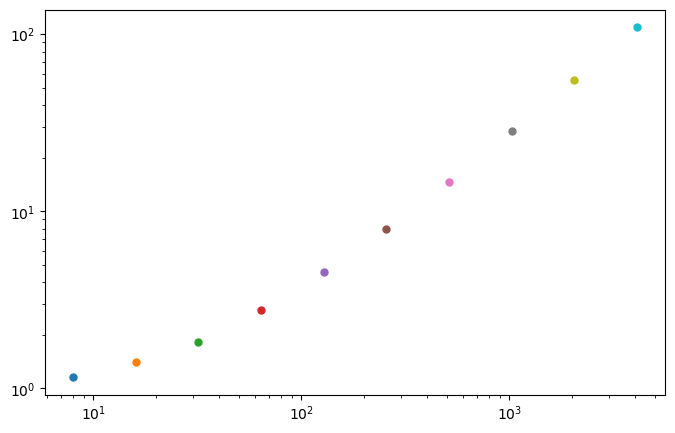

In [3]:
# Define range of N values
Nvec = 2 ** np.arange(3, 13)

# Prepare plot
plt.figure(figsize=(8, 5))
errors = []

for N in Nvec:
    h = 2 * np.pi / N
    x = -np.pi + np.arange(1, N + 1) * h
    u = np.exp(np.sin(x))
    uprime = np.cos(x) * u

    # Construct sparse 4th-order differentiation matrix
    e = np.ones(N)
    diagonals = [2/3 * e, -1/12 * e, 1/12 * e, -2/3 * e]
    offsets = [1, 2, -2, -1]
    D = diags(diagonals, offsets, shape=(N, N), format='csr')

    # Handle periodicity explicitly
    D = D.toarray()
    D[0, -1] = -2/3
    D[0, -2] = -1/12
    D[1, -1] = 1/12
    D[-1, 0] = 2/3
    D[-1, 1] = 1/12
    D[-2, 0] = -1/12
    D = (D - D.T) / h

    # Compute and store the max error
    error = np.linalg.norm(D @ u - uprime, np.inf)
    errors.append(error)
    plt.loglog(N, error, '.', markersize=10)


In [5]:
# Add reference line for N^{-4} convergence
plt.loglog(Nvec, Nvec**-4, '--', label=r'$N^{-4}$')
plt.xlabel('N')
plt.ylabel('Error')
plt.title('Convergence of 4th-order finite differences')
plt.grid(True, which="both")
plt.text(105, 5e-8, r'$N^{-4}$', fontsize=14)
plt.legend()
plt.show()

ValueError: Integers to negative integer powers are not allowed.